# Day 18 & 19 – ML Student Performance Prediction and Model Evaluation

## Objective

Build a complete machine-learning workflow using the Student Performance dataset:

1. Inspect and perform EDA.
2. Identify numerical and categorical variables.
3. Examine distributions, relationships, correlations, missing values, and potential outliers.
4. Identify factors related to `exam_score`.
5. Prepare features and preprocess the data.
6. Train and evaluate a **Linear Regression** model for `exam_score`.
7. Convert `exam_score` into **Pass/Fail** using 50 marks and train a classification model.
8. Evaluate classification using a confusion matrix, accuracy, precision, recall, and F1-score.
9. Compare training and testing performance for overfitting/underfitting.
10. Conclude with **5 meaningful insights** supported by the analysis.

> **Target for regression:** `exam_score`  
> **Classification rule:** Pass if `exam_score >= 50`, otherwise Fail.

In [1]:
# 1. Import libraries and load the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

df = pd.read_csv("Day18_19_student_habits_performance.csv")

# Treat common textual missing-value tokens as missing.
missing_tokens = ["", "NA", "N/A", "na", "n/a", "null", "NULL", "?"]
df = df.replace(missing_tokens, np.nan)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (1000, 16)


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0000,1.2000,1.1000,No,85.0000,8.0000,Fair,6,Master,Average,8,Yes,56.2000
1,S1001,20,Female,6.9000,2.8000,2.3000,No,97.3000,4.6000,Good,6,High School,Average,8,No,100.0000
2,S1002,21,Male,1.4000,3.1000,1.3000,No,94.8000,8.0000,Poor,1,High School,Poor,1,No,34.3000
3,S1003,23,Female,1.0000,3.9000,1.0000,No,71.0000,9.2000,Poor,4,Master,Good,1,Yes,26.8000
4,S1004,19,Female,5.0000,4.4000,0.5000,No,90.9000,4.9000,Fair,3,Master,Good,1,No,66.4000


## 1. Dataset Inspection

We inspect column names, data types, missing values, duplicates, and summary statistics before modeling.

In [2]:
# Basic structure
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nMissing values:")
missing = df.isnull().sum().to_frame("Missing Count")
missing["Missing %"] = 100 * missing["Missing Count"] / len(df)
display(missing)

print("Duplicate rows:", df.duplicated().sum())

print("\nNumerical summary:")
display(df.describe(include=[np.number]).T)

print("\nCategorical summary:")
display(df.describe(include=["object", "category"]).T)


Columns:
['student_id', 'age', 'gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation', 'exam_score']

Data types:


,Data Type
student_id,object
age,int64
gender,object
study_hours_per_day,float64
social_media_hours,float64
netflix_hours,float64
part_time_job,object
attendance_percentage,float64
sleep_hours,float64
diet_quality,object



Missing values:


,Missing Count,Missing %
student_id,0,0.0000
age,0,0.0000
gender,0,0.0000
study_hours_per_day,0,0.0000
social_media_hours,0,0.0000
netflix_hours,0,0.0000
part_time_job,0,0.0000
attendance_percentage,0,0.0000
sleep_hours,0,0.0000
diet_quality,0,0.0000


Duplicate rows: 0

Numerical summary:


,count,mean,std,min,25%,50%,75%,max
age,1000.0000,20.4980,2.3081,17.0000,18.7500,20.0000,23.0000,24.0000
study_hours_per_day,1000.0000,3.5501,1.4689,0.0000,2.6000,3.5000,4.5000,8.3000
social_media_hours,1000.0000,2.5055,1.1724,0.0000,1.7000,2.5000,3.3000,7.2000
netflix_hours,1000.0000,1.8197,1.0751,0.0000,1.0000,1.8000,2.5250,5.4000
attendance_percentage,1000.0000,84.1317,9.3992,56.0000,78.0000,84.4000,91.0250,100.0000
sleep_hours,1000.0000,6.4701,1.2264,3.2000,5.6000,6.5000,7.3000,10.0000
exercise_frequency,1000.0000,3.0420,2.0254,0.0000,1.0000,3.0000,5.0000,6.0000
mental_health_rating,1000.0000,5.4380,2.8475,1.0000,3.0000,5.0000,8.0000,10.0000
exam_score,1000.0000,69.6015,16.8886,18.4000,58.4750,70.5000,81.3250,100.0000



Categorical summary:


,count,unique,top,freq
student_id,1000,1000,S1999,1
gender,1000,3,Female,481
part_time_job,1000,2,No,785
diet_quality,1000,3,Fair,437
parental_education_level,909,3,High School,392
internet_quality,1000,3,Good,447
extracurricular_participation,1000,2,No,682


## 2. Identify Numerical and Categorical Variables

Numerical variables are suitable for numerical statistical analysis and scaling. Categorical variables require encoding before they can be used by most scikit-learn regression/classification algorithms.

In [3]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = [c for c in df.columns if c not in numeric_cols]

print("Numerical variables:")
print(numeric_cols)

print("\nCategorical variables:")
print(categorical_cols)


Numerical variables:
['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'exam_score']

Categorical variables:
['student_id', 'gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


## 3. Exploratory Data Analysis

### 3.1 Distribution of the Target

The distribution of `exam_score` helps us understand the overall performance pattern and whether the target contains unusual values.

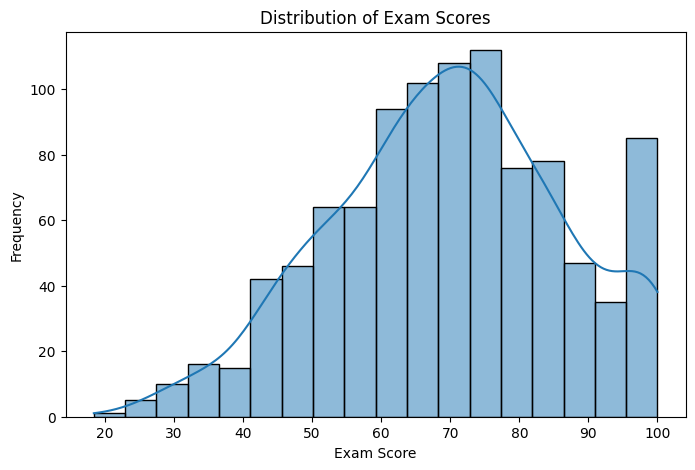

count   1000.0000
mean      69.6015
std       16.8886
min       18.4000
25%       58.4750
50%       70.5000
75%       81.3250
max      100.0000
Name: exam_score, dtype: float64


In [4]:
# Exam score distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["exam_score"], kde=True)
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")
plt.show()

print(df["exam_score"].describe())


### 3.2 Numerical Distributions

Histograms are used to inspect the distributions of numerical variables.

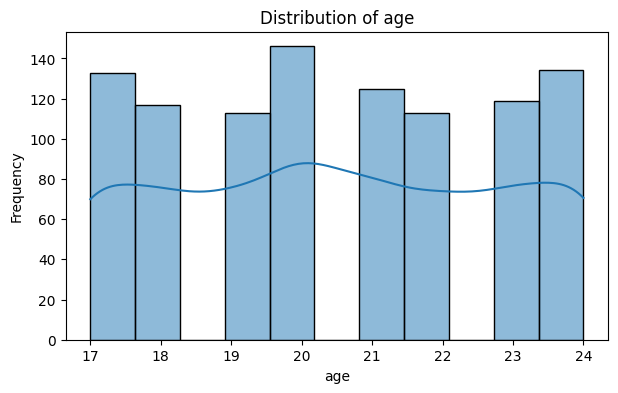

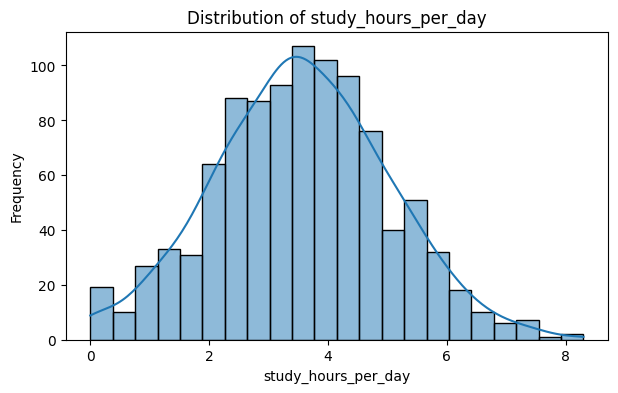

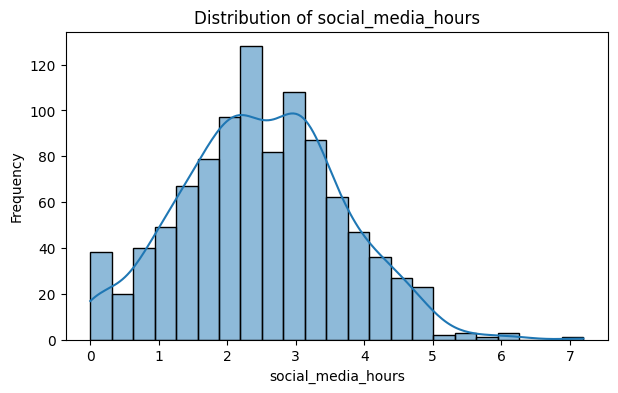

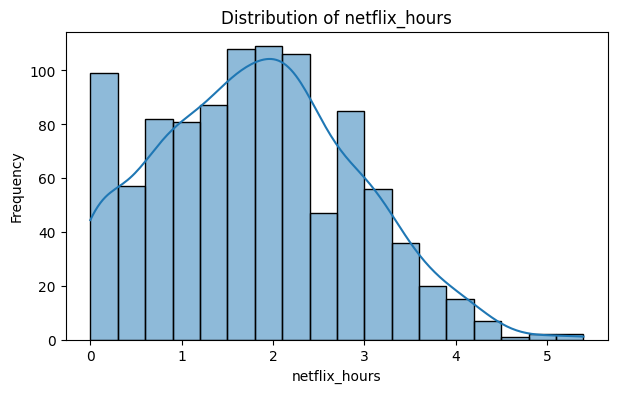

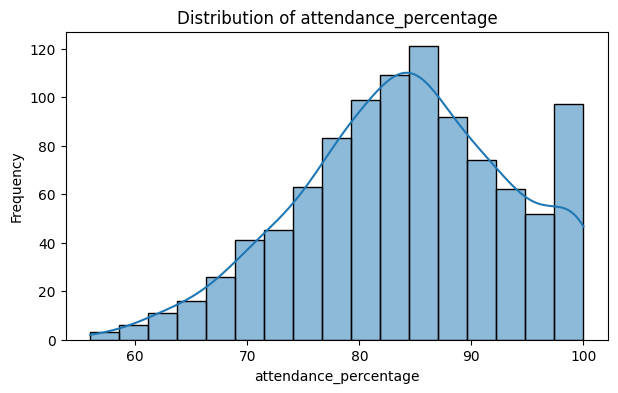

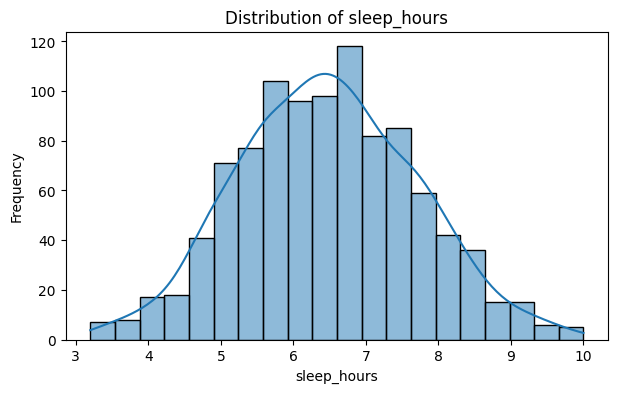

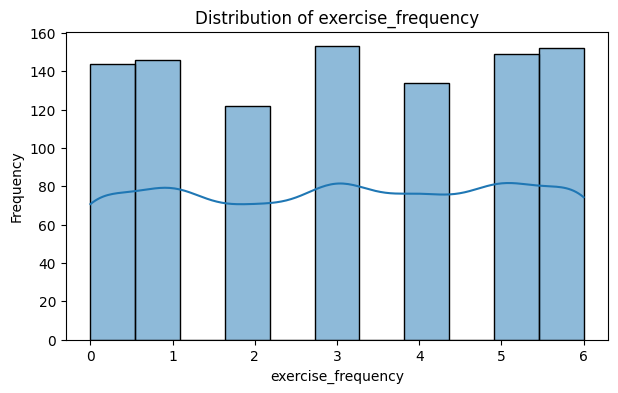

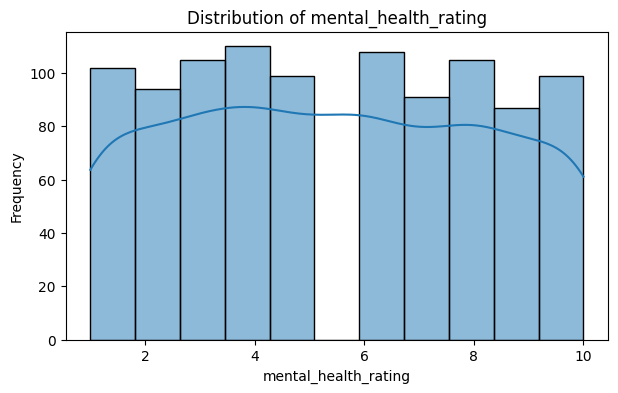

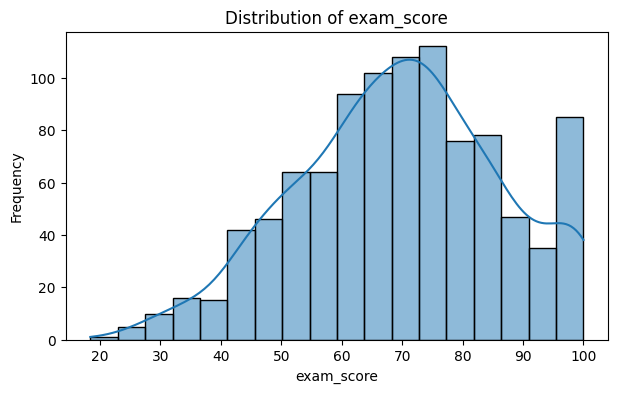

In [5]:
# Histograms for numerical variables
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


### 3.3 Correlation Analysis

For numerical variables, Pearson correlation measures the strength and direction of a linear relationship.

**Formula:**

$$r = \frac{\operatorname{Cov}(X,Y)}{\sigma_X\sigma_Y}$$

A positive value means that the variables tend to increase together; a negative value means one tends to decrease as the other increases. Correlation does **not** prove causation.

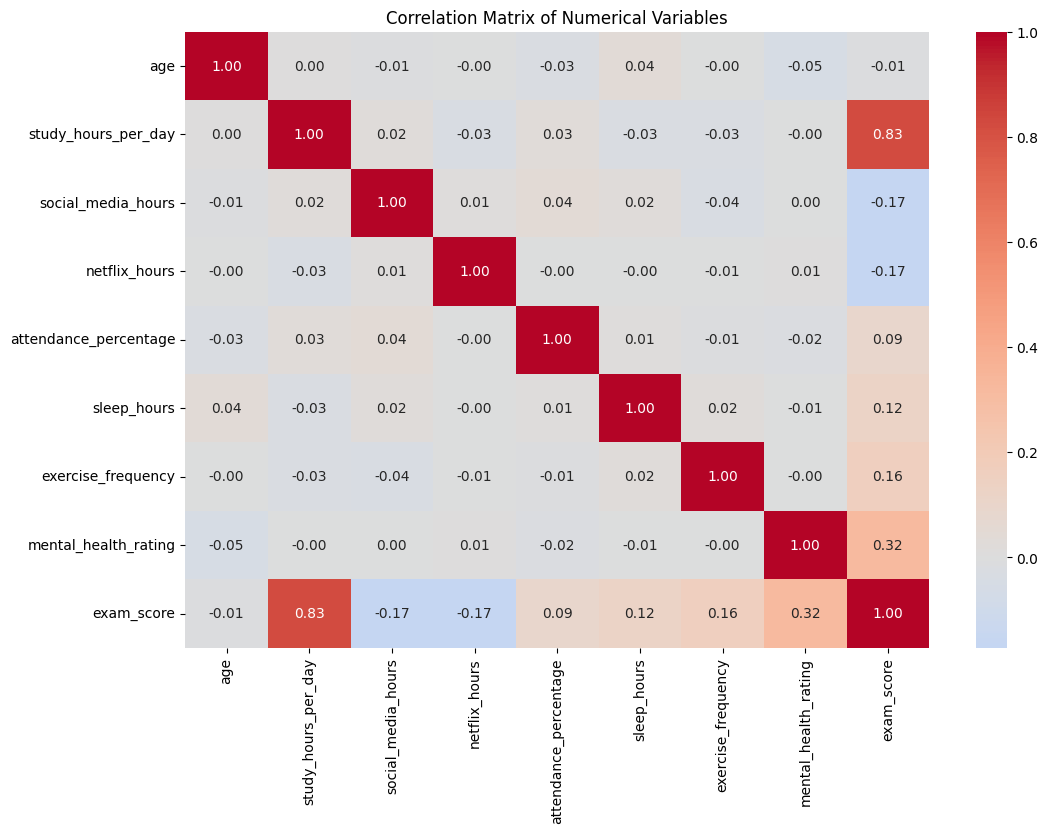

Correlation with exam_score:


,Correlation
study_hours_per_day,0.8254
mental_health_rating,0.3215
netflix_hours,-0.1718
social_media_hours,-0.1667
exercise_frequency,0.1601
sleep_hours,0.1217
attendance_percentage,0.0898
age,-0.0089


In [6]:
# Correlation matrix
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

# Correlation of all numerical variables with exam_score
target_corr = corr["exam_score"].drop("exam_score").sort_values(
    key=lambda x: x.abs(), ascending=False
)

print("Correlation with exam_score:")
display(target_corr.to_frame("Correlation"))


### 3.4 Relationships with Exam Score

Scatter plots help visually inspect the relationship between `exam_score` and numerical predictors.

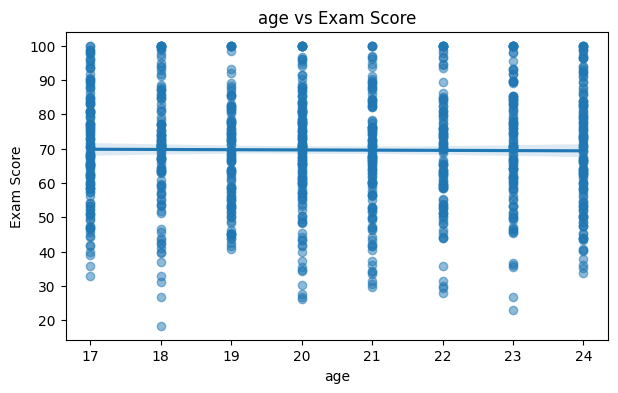

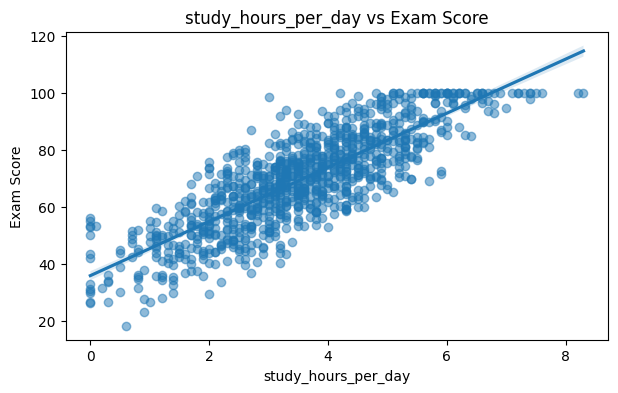

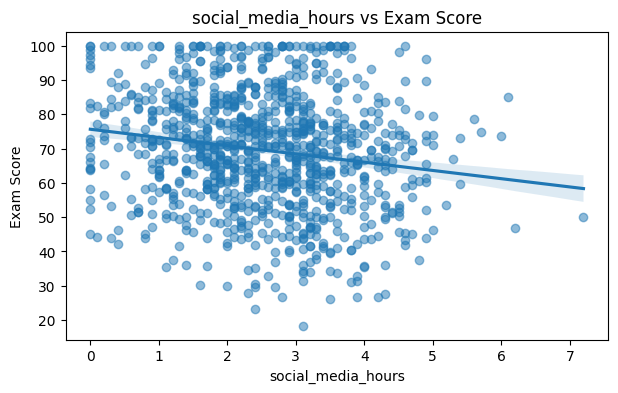

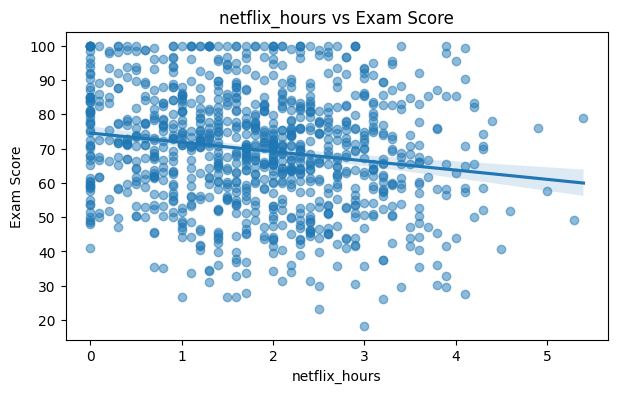

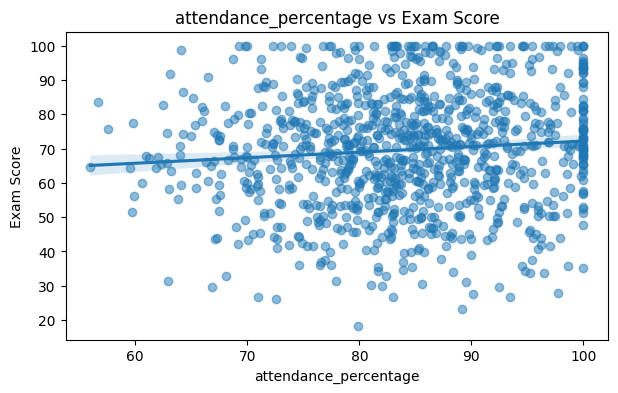

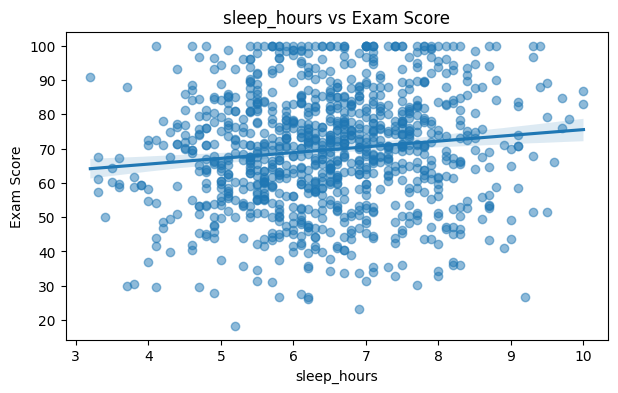

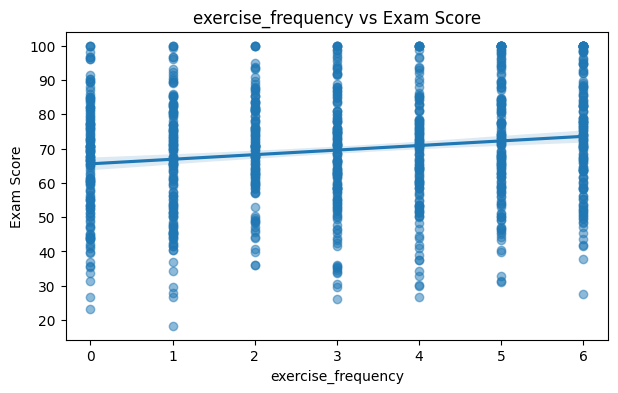

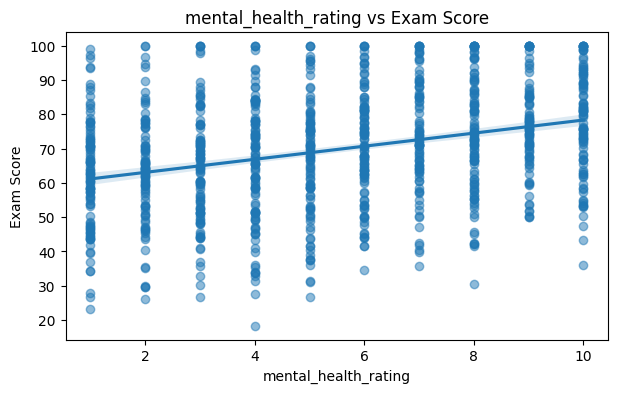

In [7]:
# Scatter plots against exam_score
for col in numeric_cols:
    if col != "exam_score":
        plt.figure(figsize=(7, 4))
        sns.regplot(data=df, x=col, y="exam_score",
                    scatter_kws={"alpha": 0.5},
                    line_kws={})
        plt.title(f"{col} vs Exam Score")
        plt.xlabel(col)
        plt.ylabel("Exam Score")
        plt.show()


### 3.5 Categorical Variables vs Exam Score

For categorical predictors, boxplots help compare exam-score distributions across categories.

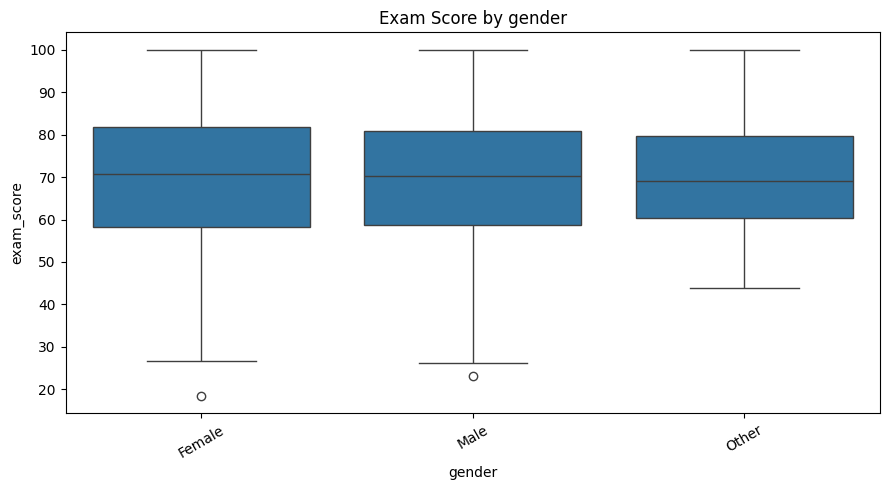

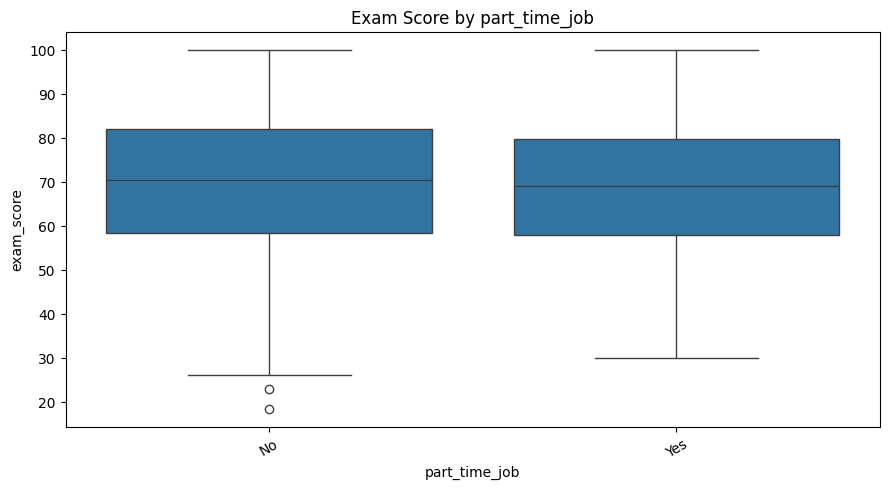

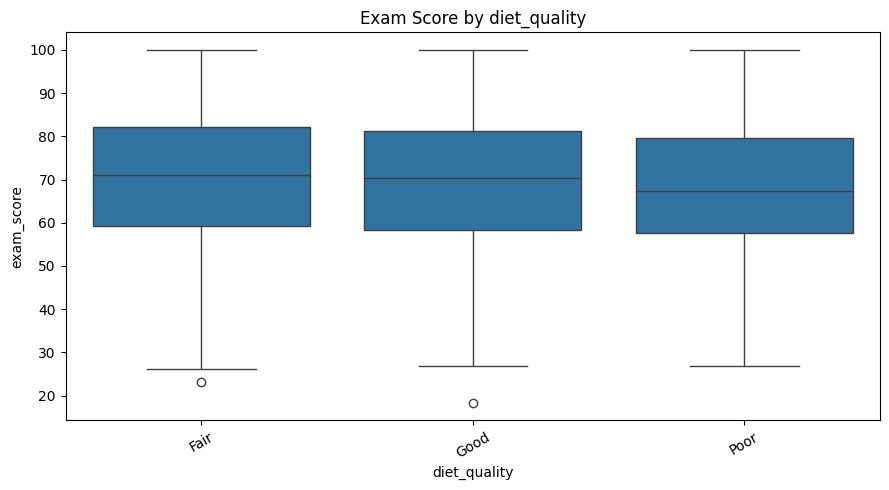

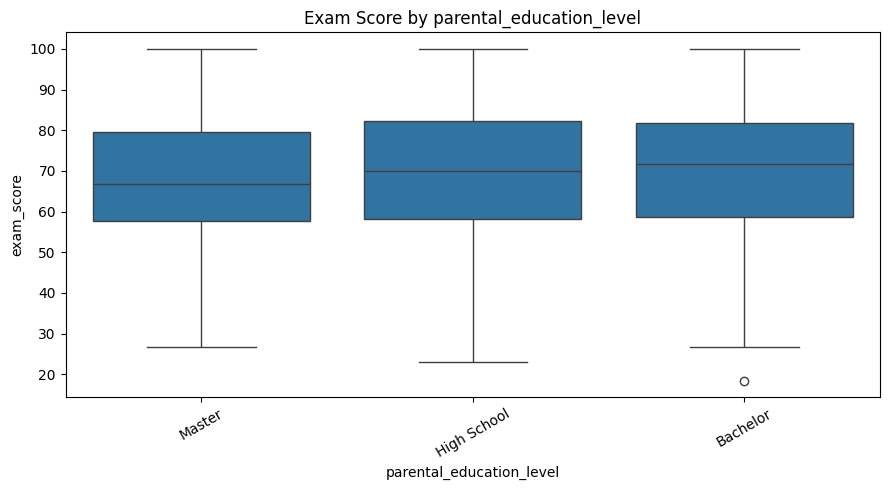

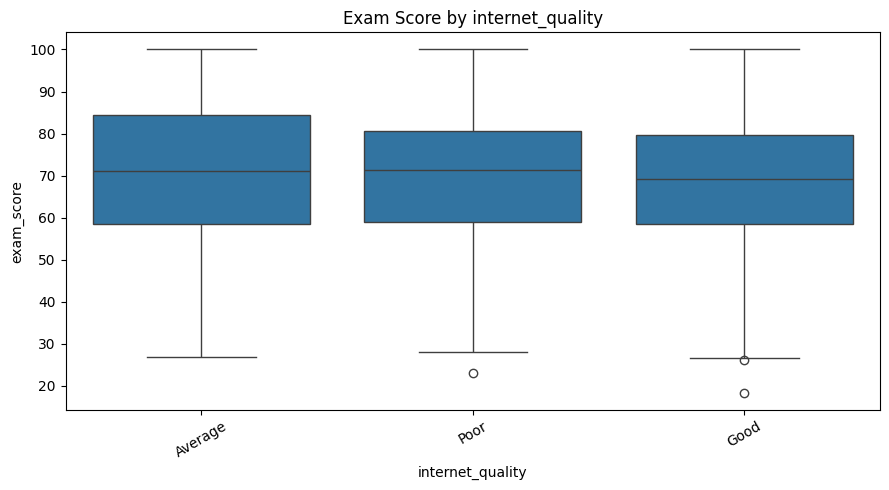

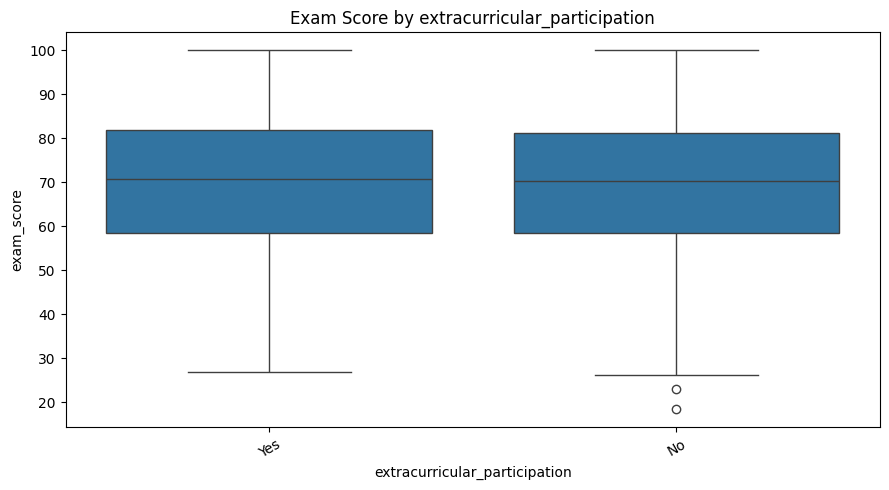

In [8]:
# Categorical relationships with exam_score
for col in categorical_cols:
    # Avoid plots with extremely high cardinality
    if df[col].nunique(dropna=True) <= 15:
        plt.figure(figsize=(9, 5))
        sns.boxplot(data=df, x=col, y="exam_score")
        plt.title(f"Exam Score by {col}")
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()


### 3.6 Potential Outliers

The IQR rule identifies potential numerical outliers.

**Formula:**

- $IQR = Q3-Q1$
- Lower fence = $Q1 - 1.5(IQR)$
- Upper fence = $Q3 + 1.5(IQR)$

Values outside these fences are flagged as potential outliers. An outlier is not automatically an error, so we do not delete observations solely because they are flagged.

,Q1,Q3,IQR,Lower Fence,Upper Fence,Potential Outliers
Variable,,,,,,
age,18.7500,23.0000,4.2500,12.3750,29.3750,0
study_hours_per_day,2.6000,4.5000,1.9000,-0.2500,7.3500,7
social_media_hours,1.7000,3.3000,1.6000,-0.7000,5.7000,5
netflix_hours,1.0000,2.5250,1.5250,-1.2875,4.8125,4
attendance_percentage,78.0000,91.0250,13.0250,58.4625,110.5625,3
sleep_hours,5.6000,7.3000,1.7000,3.0500,9.8500,2
exercise_frequency,1.0000,5.0000,4.0000,-5.0000,11.0000,0
mental_health_rating,3.0000,8.0000,5.0000,-4.5000,15.5000,0
exam_score,58.4750,81.3250,22.8500,24.2000,115.6000,2


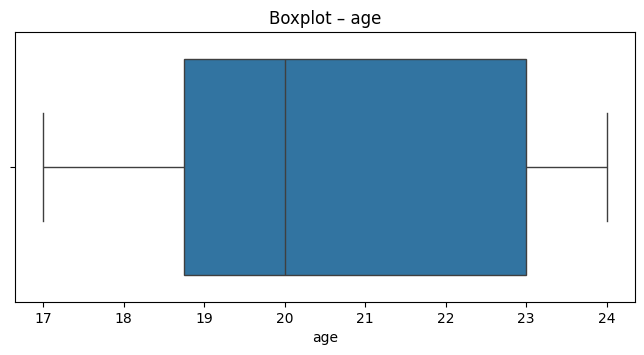

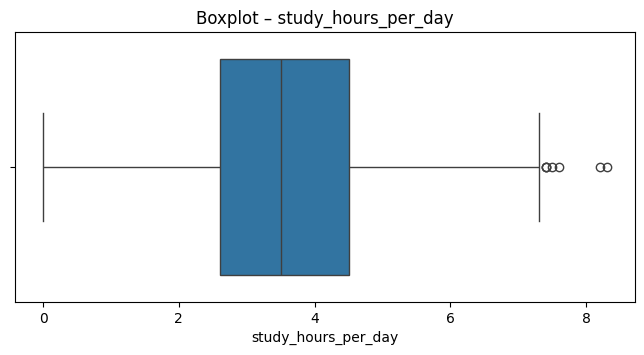

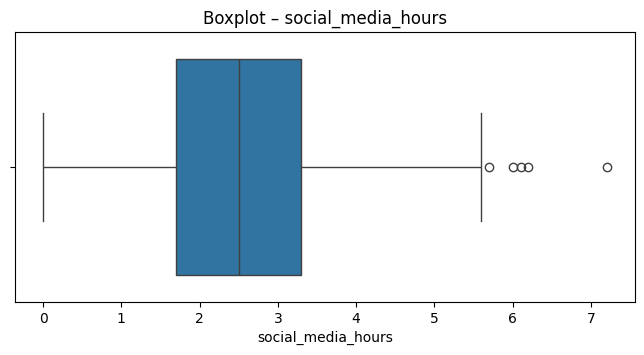

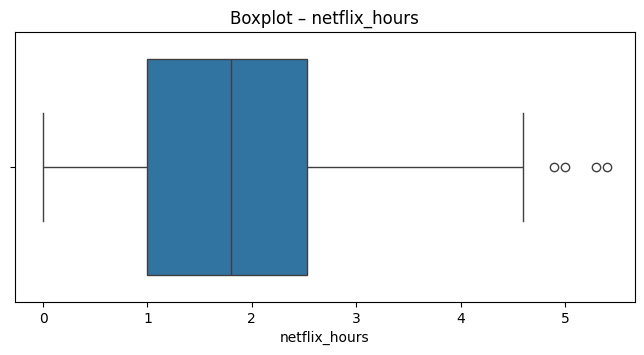

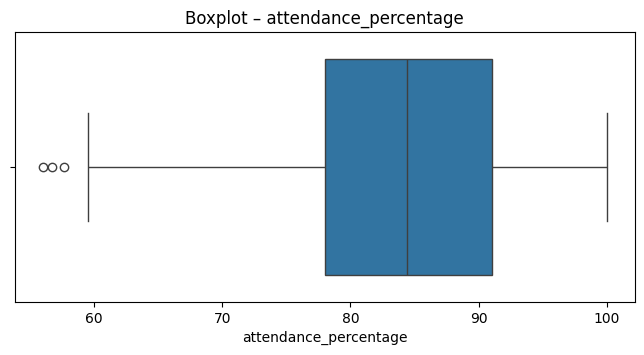

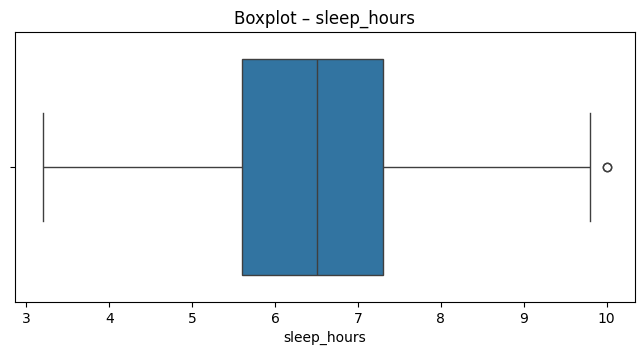

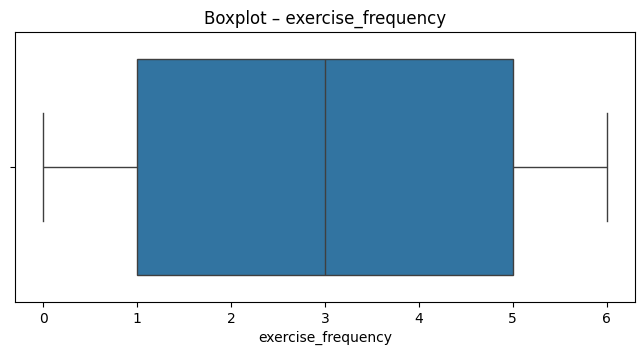

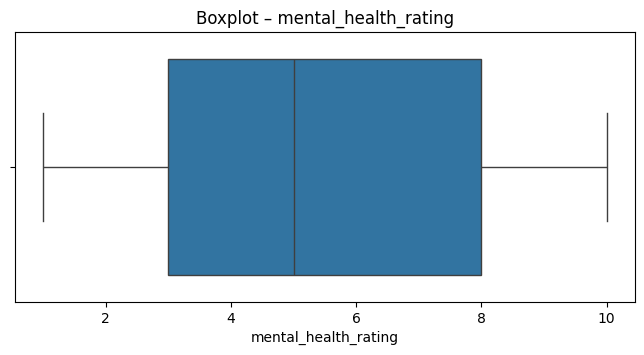

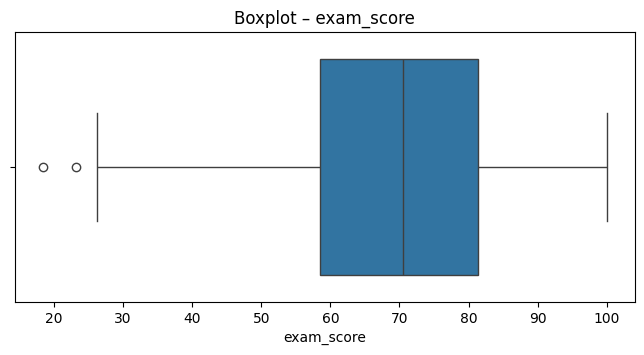

In [9]:
# IQR-based outlier summary
outlier_rows = []

for col in numeric_cols:
    s = df[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((s < lower) | (s > upper)).sum()

    outlier_rows.append({
        "Variable": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Fence": lower,
        "Upper Fence": upper,
        "Potential Outliers": int(count)
    })

outlier_table = pd.DataFrame(outlier_rows).set_index("Variable")
display(outlier_table)

# Boxplots for numerical variables
for col in numeric_cols:
    plt.figure(figsize=(8, 3.5))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot – {col}")
    plt.xlabel(col)
    plt.show()


## 4. EDA Findings: Factors Related to Exam Score

We rank numerical variables by the absolute value of their correlation with `exam_score`. For categorical variables, group means are calculated where applicable.

The strongest association should be interpreted as a **relationship in this dataset**, not as proof that the factor causes exam performance.

In [10]:
# Numerical factors ranked by absolute correlation
print("Numerical variables ranked by absolute correlation with exam_score:")
display(target_corr.to_frame("Correlation"))

# Group mean analysis for manageable categorical variables
for col in categorical_cols:
    if df[col].nunique(dropna=True) <= 15:
        print(f"\nMean exam score by {col}:")
        display(
            df.groupby(col, dropna=False)["exam_score"]
              .agg(["count", "mean", "median"])
              .sort_values("mean", ascending=False)
        )


Numerical variables ranked by absolute correlation with exam_score:


,Correlation
study_hours_per_day,0.8254
mental_health_rating,0.3215
netflix_hours,-0.1718
social_media_hours,-0.1667
exercise_frequency,0.1601
sleep_hours,0.1217
attendance_percentage,0.0898
age,-0.0089



Mean exam score by gender:


,count,mean,median
gender,,,
Other,42,70.6476,69.0000
Female,481,69.7414,70.7000
Male,477,69.3683,70.2000



Mean exam score by part_time_job:


...

,count,mean,median
parental_education_level,,,
Bachelor,350,70.2726,71.7000
NaN,91,70.0341,71.0000
High School,392,69.5472,69.9500
Master,167,68.0868,66.8000



Mean exam score by internet_quality:


,count,mean,median
internet_quality,,,
Average,391,70.6440,71.0000
Poor,162,69.7173,71.4000
Good,447,68.6477,69.3000



Mean exam score by extracurricular_participation:


,count,mean,median
extracurricular_participation,,,
Yes,318,69.6233,70.6500
No,682,69.5913,70.3500


## 5. Data Preparation for Machine Learning

`exam_score` is the regression target.

We use the remaining variables as candidate predictors. Numeric features are median-imputed and standardized. Categorical features are imputed with their most frequent value and one-hot encoded.

Using a scikit-learn `Pipeline` and `ColumnTransformer` ensures that preprocessing is learned from the training data and applied consistently to the test data.

In [11]:
# Define regression features and target
target = "exam_score"

X = df.drop(columns=[target])
y = pd.to_numeric(df[target], errors="coerce")

# Remove rows where the regression target itself is unavailable.
valid_target = y.notna()
X = X.loc[valid_target].copy()
y = y.loc[valid_target].copy()

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

print("Regression features:")
print(X.columns.tolist())
print("\nNumeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Usable rows:", len(y))


Regression features:
['student_id', 'age', 'gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation']

Numeric features: ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating']
Categorical features: ['student_id', 'gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']
Usable rows: 1000


In [12]:
# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))


Training rows: 800
Testing rows: 200


## 6. Linear Regression – Predicting Exam Score

### Model

Linear regression models the target as:

$$\hat{y}=b_0+b_1x_1+b_2x_2+\cdots+b_px_p$$

The model is trained on the prepared training data and then used to predict exam scores for both training and testing sets.

In [13]:
# Linear Regression pipeline
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

linear_model.fit(X_train, y_train)

y_train_pred = linear_model.predict(X_train)
y_test_pred = linear_model.predict(X_test)

print("First 10 test predictions:")
display(pd.DataFrame({
    "Actual Exam Score": y_test.iloc[:10].values,
    "Predicted Exam Score": y_test_pred[:10]
}))


First 10 test predictions:


,Actual Exam Score,Predicted Exam Score
0,64.2000,66.2066
1,72.7000,75.1114
2,79.0000,78.0462
3,79.5000,73.3346
4,58.2000,61.0286
5,53.4000,54.0777
6,70.8000,75.5662
7,62.5000,55.0597
8,36.8000,40.7141
9,67.6000,72.4161


## 7. Regression Model Evaluation

The following metrics evaluate prediction quality:

- **MAE:** $MAE=\frac{1}{n}\sum|y_i-\hat{y}_i|$ — average absolute prediction error.
- **MSE:** $MSE=\frac{1}{n}\sum(y_i-\hat{y}_i)^2$ — penalizes larger errors more strongly.
- **RMSE:** $RMSE=\sqrt{MSE}$ — error in the same units as exam score.
- **R²:** $R^2=1-\frac{SS_{res}}{SS_{tot}}$ — proportion of target variance explained by the model.

In [14]:
# Regression metrics
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

regression_results = pd.DataFrame({
    "Training": regression_metrics(y_train, y_train_pred),
    "Testing": regression_metrics(y_test, y_test_pred)
}).T

display(regression_results)

print(f"Test MAE: {regression_results.loc['Testing', 'MAE']:.4f}")
print(f"Test RMSE: {regression_results.loc['Testing', 'RMSE']:.4f}")
print(f"Test R²: {regression_results.loc['Testing', 'R2']:.4f}")


,MAE,MSE,RMSE,R2
Training,0.0000,0.0000,0.0000,1.0000
Testing,4.1926,26.5440,5.1521,0.8965


Test MAE: 4.1926
Test RMSE: 5.1521
Test R²: 0.8965


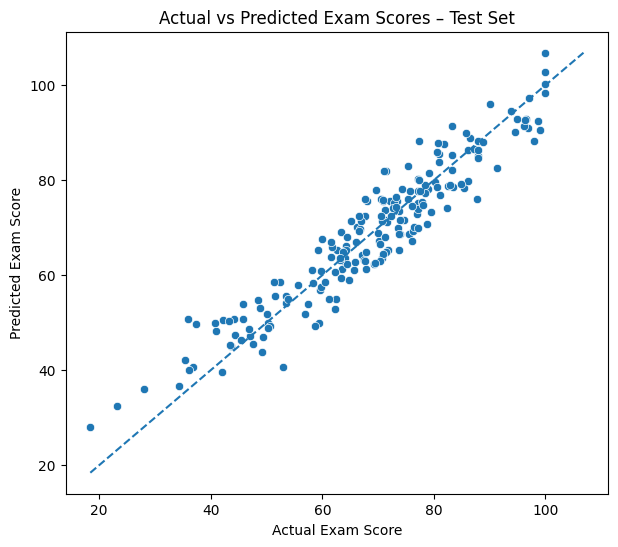

In [15]:
# Actual vs predicted exam scores
plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=y_test_pred)
min_score = min(y_test.min(), y_test_pred.min())
max_score = max(y_test.max(), y_test_pred.max())
plt.plot([min_score, max_score], [min_score, max_score], linestyle="--")
plt.title("Actual vs Predicted Exam Scores – Test Set")
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.show()


## 8. Classification: Pass vs Fail

Create a binary target from `exam_score`:

$$Pass=\begin{cases}1,&exam\_score\ge50\\0,&exam\_score<50\end{cases}$$

We use **Logistic Regression**, an appropriate classification algorithm for a binary target. The same prepared feature set is used, while the original `exam_score` is removed from the predictors to avoid target leakage.

In [16]:
# Create Pass/Fail target without using exam_score as a predictor
y_class = (y >= 50).astype(int)

X_class = X.copy()

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_class, y_class, test_size=0.20, random_state=42, stratify=y_class
)

print("Class distribution:")
print(y_class.value_counts().rename(index={0: "Fail", 1: "Pass"}))


Class distribution:
exam_score
Pass    869
Fail    131
Name: count, dtype: int64


In [17]:
# Logistic Regression classification pipeline
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

logistic_model.fit(Xc_train, yc_train)

yc_train_pred = logistic_model.predict(Xc_train)
yc_test_pred = logistic_model.predict(Xc_test)

print("First 10 test classifications:")
display(pd.DataFrame({
    "Actual": np.where(yc_test.iloc[:10].values == 1, "Pass", "Fail"),
    "Predicted": np.where(yc_test_pred[:10] == 1, "Pass", "Fail")
}))


First 10 test classifications:


,Actual,Predicted
0,Pass,Pass
1,Pass,Fail
2,Pass,Pass
3,Pass,Pass
4,Pass,Pass
5,Pass,Pass
6,Pass,Pass
7,Pass,Pass
8,Pass,Pass
9,Pass,Pass


## 9. Classification Evaluation

### Confusion Matrix

For binary classification:

- **True Positive (TP):** correctly predicted Pass
- **True Negative (TN):** correctly predicted Fail
- **False Positive (FP):** predicted Pass but actually Fail
- **False Negative (FN):** predicted Fail but actually Pass

### Metrics

- **Accuracy:** $\frac{TP+TN}{TP+TN+FP+FN}$
- **Precision:** $\frac{TP}{TP+FP}$
- **Recall:** $\frac{TP}{TP+FN}$
- **F1-score:** $2\frac{Precision\times Recall}{Precision+Recall}$

In [18]:
# Classification metrics
def classification_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0)
    }

classification_results = pd.DataFrame({
    "Training": classification_metrics(yc_train, yc_train_pred),
    "Testing": classification_metrics(yc_test, yc_test_pred)
}).T

display(classification_results)

print("Detailed test classification report:")
print(classification_report(
    yc_test, yc_test_pred,
    target_names=["Fail", "Pass"],
    zero_division=0
))


,Accuracy,Precision,Recall,F1-Score
Training,0.9800,0.9843,0.9928,0.9885
Testing,0.9550,0.9714,0.9770,0.9742


Detailed test classification report:
              precision    recall  f1-score   support

        Fail       0.84      0.81      0.82        26
        Pass       0.97      0.98      0.97       174

    accuracy                           0.95       200
   macro avg       0.91      0.89      0.90       200
weighted avg       0.95      0.95      0.95       200



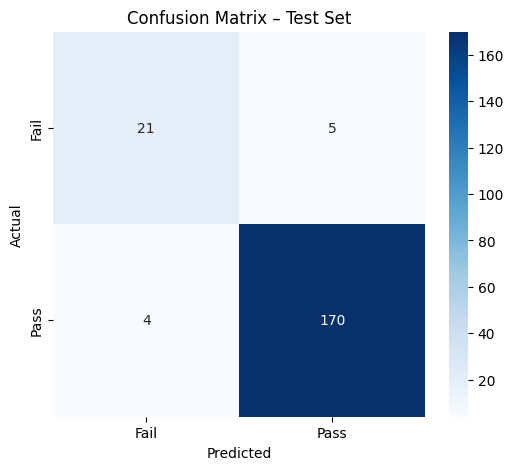

TN = 21, FP = 5, FN = 4, TP = 170


In [19]:
# Confusion matrix – test data
cm = confusion_matrix(yc_test, yc_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)
plt.title("Confusion Matrix – Test Set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN = {tn}, FP = {fp}, FN = {fn}, TP = {tp}")


## 10. Overfitting and Underfitting Analysis

A model is potentially **overfitting** when training performance is much better than testing performance.

A model is potentially **underfitting** when both training and testing performance are poor.

We compare:
- Regression: Training vs Testing **R²** and error metrics.
- Classification: Training vs Testing **Accuracy, Precision, Recall and F1-score**.

The gap should be considered alongside the absolute test performance.

In [20]:
# Quantify train-test gaps
reg_r2_gap = regression_results.loc["Training", "R2"] - regression_results.loc["Testing", "R2"]
reg_rmse_gap = regression_results.loc["Testing", "RMSE"] - regression_results.loc["Training", "RMSE"]

cls_acc_gap = classification_results.loc["Training", "Accuracy"] - classification_results.loc["Testing", "Accuracy"]
cls_f1_gap = classification_results.loc["Training", "F1-Score"] - classification_results.loc["Testing", "F1-Score"]

print(f"Regression R² train-test gap: {reg_r2_gap:.4f}")
print(f"Regression RMSE test-train increase: {reg_rmse_gap:.4f}")
print(f"Classification accuracy train-test gap: {cls_acc_gap:.4f}")
print(f"Classification F1 train-test gap: {cls_f1_gap:.4f}")

# A descriptive, not absolute, interpretation
if abs(reg_r2_gap) < 0.10:
    reg_fit_comment = "The regression train-test R² gap is relatively small, suggesting limited evidence of overfitting."
else:
    reg_fit_comment = "The regression train-test R² gap is noticeable, suggesting possible overfitting."

if abs(cls_acc_gap) < 0.10:
    cls_fit_comment = "The classification train-test accuracy gap is relatively small, suggesting limited evidence of overfitting."
else:
    cls_fit_comment = "The classification train-test accuracy gap is noticeable, suggesting possible overfitting."

print("\nRegression:", reg_fit_comment)
print("Classification:", cls_fit_comment)


Regression R² train-test gap: 0.1035
Regression RMSE test-train increase: 5.1521
Classification accuracy train-test gap: 0.0250
Classification F1 train-test gap: 0.0143

Regression: The regression train-test R² gap is noticeable, suggesting possible overfitting.
Classification: The classification train-test accuracy gap is relatively small, suggesting limited evidence of overfitting.


## 11. Most Important Model Findings

For linear regression, the one-hot encoded model contains coefficients for the processed features. Because numeric features are standardized, their coefficients can be compared approximately by magnitude. Categorical coefficients represent changes relative to the relevant reference category.

The coefficient analysis is interpreted as model association, not causal impact.

In [21]:
# Extract linear regression feature coefficients
fitted_preprocessor = linear_model.named_steps["preprocessor"]
regressor = linear_model.named_steps["regressor"]

try:
    feature_names = fitted_preprocessor.get_feature_names_out()
    coefficients = regressor.coef_

    coef_table = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": coefficients,
        "Absolute Coefficient": np.abs(coefficients)
    }).sort_values("Absolute Coefficient", ascending=False)

    print("Top model coefficients by absolute magnitude:")
    display(coef_table.head(15))
except Exception as e:
    print("Feature coefficient extraction was not available:", e)


Top model coefficients by absolute magnitude:


,Feature,Coefficient,Absolute Coefficient
245,cat__student_id_S1286,-21.9191,21.9191
373,cat__student_id_S1436,-21.5338,21.5338
115,cat__student_id_S1122,-20.2374,20.2374
388,cat__student_id_S1456,-19.7829,19.7829
465,cat__student_id_S1550,15.6442,15.6442
323,cat__student_id_S1376,15.3398,15.3398
471,cat__student_id_S1557,15.0132,15.0132
253,cat__student_id_S1296,14.6689,14.6689
34,cat__student_id_S1033,14.3333,14.3333
1,num__study_hours_per_day,14.1270,14.1270


## 12. Five Meaningful Insights

The final observations below are generated from the actual EDA and model results, so they remain tied to the supplied dataset rather than using generic statements.

In [22]:
# Generate five dataset-supported insights
strongest_corr_feature = target_corr.index[0] if len(target_corr) else "No numerical predictor"
strongest_corr_value = target_corr.iloc[0] if len(target_corr) else np.nan

best_cat_text = None
cat_effects = []
for col in categorical_cols:
    if df[col].nunique(dropna=True) <= 15:
        means = df.groupby(col)["exam_score"].mean().dropna()
        if len(means) >= 2:
            high_cat = means.idxmax()
            low_cat = means.idxmin()
            cat_effects.append((means.max() - means.min(), col, high_cat, low_cat,
                                means.max(), means.min()))
if cat_effects:
    cat_effects.sort(reverse=True)
    _, best_col, high_cat, low_cat, high_mean, low_mean = cat_effects[0]
else:
    best_col = None

outlier_counts = outlier_table["Potential Outliers"].sort_values(ascending=False)

insights = [
    f"1. Among numerical predictors, {strongest_corr_feature} has the strongest absolute "
    f"linear correlation with exam_score (r = {strongest_corr_value:.4f}), making it the "
    f"most prominent numerical factor in the initial EDA.",
    f"2. The Linear Regression model achieved a test R² of "
    f"{regression_results.loc['Testing', 'R2']:.4f} with a test RMSE of "
    f"{regression_results.loc['Testing', 'RMSE']:.4f}, indicating how well the selected "
    f"student-habit and demographic features explain/predict exam-score variation.",
    f"3. The classification model achieved test accuracy of "
    f"{classification_results.loc['Testing', 'Accuracy']:.4f} and test F1-score of "
    f"{classification_results.loc['Testing', 'F1-Score']:.4f} when predicting Pass/Fail "
    f"using the 50-mark threshold.",
    f"4. The largest number of IQR-flagged potential outliers occurs in "
    f"{outlier_counts.index[0]} ({int(outlier_counts.iloc[0])} observations), showing "
    f"that this variable has the most extreme observations among the numeric features inspected.",
    f"5. The regression and classification train-test gaps were "
    f"{reg_r2_gap:.4f} for R² and {cls_acc_gap:.4f} for accuracy. These gaps provide evidence "
    f"for assessing generalization; a small gap suggests similar behavior on unseen data, "
    f"whereas a large positive training advantage suggests overfitting."
]

for insight in insights:
    print(insight)

if best_col:
    print(
        f"\nAdditional categorical EDA finding: {best_col} shows the largest difference "
        f"between its highest and lowest group mean exam scores "
        f"({high_mean:.2f} vs {low_mean:.2f})."
    )


1. Among numerical predictors, study_hours_per_day has the strongest absolute linear correlation with exam_score (r = 0.8254), making it the most prominent numerical factor in the initial EDA.
2. The Linear Regression model achieved a test R² of 0.8965 with a test RMSE of 5.1521, indicating how well the selected student-habit and demographic features explain/predict exam-score variation.
3. The classification model achieved test accuracy of 0.9550 and test F1-score of 0.9742 when predicting Pass/Fail using the 50-mark threshold.
4. The largest number of IQR-flagged potential outliers occurs in study_hours_per_day (7 observations), showing that this variable has the most extreme observations among the numeric features inspected.
5. The regression and classification train-test gaps were 0.1035 for R² and 0.0250 for accuracy. These gaps provide evidence for assessing generalization; a small gap suggests similar behavior on unseen data, whereas a large positive training advantage suggests 

## Final Conclusion

This notebook completed the requested Day 18 & 19 machine-learning workflow:

- Dataset inspection and EDA
- Numerical/categorical variable identification
- Missing-value and duplicate inspection
- Distribution and outlier analysis
- Correlation and relationship analysis with `exam_score`
- Preprocessing with imputation, scaling, and one-hot encoding
- Train/test split
- Linear Regression for exam-score prediction
- MAE, MSE, RMSE and R² evaluation
- Pass/Fail classification at the 50-mark threshold
- Logistic Regression classification
- Confusion matrix, accuracy, precision, recall and F1-score
- Training-vs-testing comparison for overfitting/underfitting
- Model coefficient inspection
- Five data-supported student-performance insights

### Key caution

EDA associations and model coefficients show patterns in this dataset. They should not be interpreted as proof that a particular habit or characteristic **causes** higher or lower exam performance.